**RAYMER / PHYSICS-BASED AERODYNAMIC MODEL**

In [1]:
# ============================================================
# TBM-X — 07 RAYMER / PHYSICS-BASED AERODYNAMIC MODEL
# ============================================================
#
# TARGET:
#
#   Aircraft Geometry
#          ↓
#   Aspect Ratio / Wetted Area
#          ↓
#   Parasite Drag
#          ↓
#   Induced Drag
#          ↓
#   Total Drag
#          ↓
#   L/D
#          ↓
#   Required Power
#
# Bu notebook 04_RAYMER_MISSION_ANALYSIS içinde kullanılan
# basitleştirilmiş aerodynamic modelin geliştirilmiş halidir..
#
# Ana ilişkiler:
#
#       CD = CD0 + CDi
#
#       CDi = k CL²
#
#       k = 1 / (π e AR)
#
#       L/D = CL / CD
#
# ============================================================
#
# METHOD STATUS
# -------------
# Raymer-inspired conceptual aerodynamic model
# + engineering assumptions
# + benchmark validation
#
# Bu model CFD değildir.
# Bu model high-fidelity aerodynamic analysis değildir.
#
# Amaç: conceptual aircraft design seviyesinde
# fiziksel olarak izlenebilir bir aerodynamic model
# oluşturmaktır.
#
# ============================================================

**LIBRARIES**

In [2]:
# ============================================================
# LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

print("Libraries loaded successfully.")

Libraries loaded successfully.


**WORKING DIRECTORY**

In [3]:
# ============================================================
# WORKING DIRECTORY
# ============================================================

current_dir = Path.cwd()

print("Current working directory:")
print(current_dir)

Current working directory:
C:\Users\musta\Documents\RAYMER\TBM-X_v0.2_data_engineering


**INPUTS FROM PREVIOUS DESIGN STAGES**

***TBM-X DESIGN INPUTS***

In [6]:
# ============================================================
# TBM-X DESIGN INPUTS
# ============================================================
#
# Bu değerler 05 ve 06 notebook'larından gelmektedir.
#
# İlk versiyonda notebook'lar arası bağlantıyı manuel tutuyoruz.
# Daha sonra bunları ortak configuration / pipeline üzerinden
# otomatik bağlayacağız.
# ============================================================

MTOW_kg = 1689.0

wing_area_m2 = 13.44

aspect_ratio = 9.15

wing_span_m = np.sqrt(
    aspect_ratio * wing_area_m2
)

mean_chord_m = (
    wing_area_m2 / wing_span_m
)

print(f"MTOW          : {MTOW_kg:.1f} kg")
print(f"Wing area     : {wing_area_m2:.2f} m²")
print(f"Aspect ratio  : {aspect_ratio:.2f}")
print(f"Wing span     : {wing_span_m:.2f} m")
print(f"Mean chord    : {mean_chord_m:.2f} m")

MTOW          : 1689.0 kg
Wing area     : 13.44 m²
Aspect ratio  : 9.15
Wing span     : 11.09 m
Mean chord    : 1.21 m


**FLIGHT CONDITION**

In [7]:
# ============================================================
# FLIGHT CONDITION
# ============================================================

g = 9.80665

cruise_speed_kt = 300.0
cruise_speed_ms = cruise_speed_kt * 0.514444

cruise_altitude_ft = 25000.0
cruise_altitude_m = cruise_altitude_ft * 0.3048

print(f"Cruise speed    : {cruise_speed_ms:.2f} m/s")
print(f"Cruise altitude : {cruise_altitude_m:.1f} m")

Cruise speed    : 154.33 m/s
Cruise altitude : 7620.0 m


**ISA ATMOSPHERE**

In [8]:
# ============================================================
# ISA ATMOSPHERE
# ============================================================

def isa_atmosphere(altitude_m):
    """
    Simplified ISA atmosphere model.

    Returns:
        Temperature [K]
        Pressure [Pa]
        Density [kg/m³]
    """

    T0 = 288.15
    P0 = 101325.0

    lapse_rate = 0.0065

    R = 287.05
    g = 9.80665

    T = T0 - lapse_rate * altitude_m

    P = P0 * (
        T / T0
    ) ** (
        g / (R * lapse_rate)
    )

    rho = P / (R * T)

    return T, P, rho

**CRUISE ATMOSPHERE**

In [10]:
# ============================================================
# CRUISE ATMOSPHERE
# ============================================================

T_cruise, P_cruise, rho_cruise = (
    isa_atmosphere(
        cruise_altitude_m
    )
)

print(f"Temperature : {T_cruise:.2f} K")
print(f"Pressure    : {P_cruise:.1f} Pa")
print(f"Density     : {rho_cruise:.4f} kg/m³")

Temperature : 238.62 K
Pressure    : 37600.5 Pa
Density     : 0.5489 kg/m³


**BASIC FLIGHT PARAMETERS**

***DYNAMIC PRESSURE***

In [11]:
# ============================================================
# DYNAMIC PRESSURE
# ============================================================

q_cruise = (
    0.5
    * rho_cruise
    * cruise_speed_ms**2
)

print(
    f"Cruise dynamic pressure = "
    f"{q_cruise:.2f} Pa"
)

Cruise dynamic pressure = 6537.60 Pa


**AIRCRAFT WEIGHT**

In [12]:
# ============================================================
# AIRCRAFT WEIGHT
# ============================================================

weight_N = MTOW_kg * g

print(
    f"Aircraft weight = "
    f"{weight_N:.1f} N"
)

Aircraft weight = 16563.4 N


**LIFT COEFFICIENT**

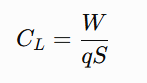

In [14]:
# ============================================================
# CRUISE LIFT COEFFICIENT
# ============================================================

CL_cruise = (
    weight_N
    / (
        q_cruise
        * wing_area_m2
    )
)

print(
    f"Cruise CL = {CL_cruise:.4f}"
)

Cruise CL = 0.1885


**REYNOLDS NUMBER**

In [15]:
# ============================================================
# REYNOLDS NUMBER
# ============================================================

def air_dynamic_viscosity(T):
    """
    Sutherland equation.

    Returns dynamic viscosity [Pa·s].
    """

    mu_ref = 1.716e-5
    T_ref = 273.15
    S = 110.4

    mu = (
        mu_ref
        * (T / T_ref) ** 1.5
        * (T_ref + S)
        / (T + S)
    )

    return mu


mu_cruise = air_dynamic_viscosity(
    T_cruise
)

Re_cruise = (
    rho_cruise
    * cruise_speed_ms
    * mean_chord_m
    / mu_cruise
)

print(
    f"Dynamic viscosity = {mu_cruise:.3e} Pa·s"
)

print(
    f"Reynolds number = {Re_cruise:.3e}"
)

Dynamic viscosity = 1.540e-05 Pa·s
Reynolds number = 6.669e+06


**PARASITE DRAG MODEL**

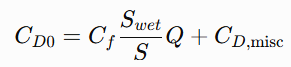

**WETTED AREA ASSUMPTION**

In [16]:
# ============================================================
# WETTED AREA MODEL
# ============================================================
#
# İlk conceptual model:
#
# S_wet / S_ref
#
# Daha sonra fuselage, wing, tail, nacelle vb. ayrı ayrı
# modellenebilir.
# ============================================================

wetted_area_ratio = 5.0

wetted_area_m2 = (
    wetted_area_ratio
    * wing_area_m2
)

print(
    f"Wetted area ratio = "
    f"{wetted_area_ratio:.2f}"
)

print(
    f"Estimated wetted area = "
    f"{wetted_area_m2:.2f} m²"
)

Wetted area ratio = 5.00
Estimated wetted area = 67.20 m²


**SKIN FRICTION**

***Turbulent Flat Plate***

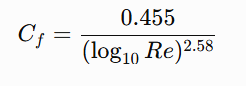

In [17]:
# ============================================================
# SKIN FRICTION COEFFICIENT
# ============================================================

def turbulent_skin_friction_coefficient(Re):
    """
    Turbulent flat-plate skin friction coefficient.

    Conceptual aircraft-design approximation.
    """

    if Re <= 0:
        return np.nan

    Cf = (
        0.455
        / (
            np.log10(Re) ** 2.58
        )
    )

    return Cf


Cf_cruise = turbulent_skin_friction_coefficient(
    Re_cruise
)

print(
    f"Skin friction coefficient Cf = "
    f"{Cf_cruise:.5f}"
)

Skin friction coefficient Cf = 0.00321


**FORM / INTERFERENCE FACTOR**

In [18]:
# ============================================================
# FORM / INTERFERENCE FACTOR
# ============================================================
#
# Q accounts conceptually for:
# - form effects
# - interference effects
# - non-ideal geometry
#
# This is an engineering assumption at this stage.
# ============================================================

form_interference_factor = 1.20

print(
    f"Form/interference factor Q = "
    f"{form_interference_factor:.2f}"
)

print(
    "Origin: Engineering Assumption"
)

Form/interference factor Q = 1.20
Origin: Engineering Assumption


**PARASITE DRAG COMPONENT**

In [19]:
# ============================================================
# PARASITE DRAG FROM SKIN FRICTION
# ============================================================

CD0_skin = (
    Cf_cruise
    * wetted_area_ratio
    * form_interference_factor
)

print(
    f"CD0 from skin friction = "
    f"{CD0_skin:.5f}"
)

CD0 from skin friction = 0.01925


**MISCELLANEOUS PARASITE DRAG**

In [20]:
# ============================================================
# MISCELLANEOUS PARASITE DRAG
# ============================================================
#
# Represents first-order effects not explicitly modeled:
# - antennas
# - landing gear doors / small protuberances
# - cooling inlets
# - gaps
# - excrescences
# - etc.
#
# Engineering assumption.
# ============================================================

CD_misc = 0.005

print(
    f"Miscellaneous CD = "
    f"{CD_misc:.5f}"
)

Miscellaneous CD = 0.00500


**SYSTEMATIC CD0**

In [21]:
# ============================================================
# SYSTEMATIC ZERO-LIFT DRAG COEFFICIENT
# ============================================================

CD0 = (
    CD0_skin
    + CD_misc
)

print(
    f"Systematic CD0 = "
    f"{CD0:.5f}"
)

Systematic CD0 = 0.02425


**INDUCED DRAG**

**OSWALD EFFICIENCY**

  ***The Oswald span efficiency factor 
e is a measure of drag due to lift effi
ciency. During cruise, 
e is approximately 0.6 to 0.8 for a fighter and 0.8 for 
other aircraft.***

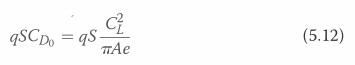

In [22]:
# ============================================================
# OSWALD EFFICIENCY
# ============================================================
#
# e represents the efficiency of the finite wing relative
# to the ideal elliptical loading case.
#
# Current value:
# Engineering assumption
#
# Later:
# - aspect ratio
# - taper
# - sweep
# - wing loading
# - empirical correlations
# can be used to improve this model.
# ============================================================

oswald_efficiency = 0.80

print(
    f"Oswald efficiency e = "
    f"{oswald_efficiency:.3f}"
)

Oswald efficiency e = 0.800


**INDUCED DRAG FACTOR**

In [23]:
# ============================================================
# INDUCED DRAG FACTOR
# ============================================================

k = (
    1
    / (
        np.pi
        * oswald_efficiency
        * aspect_ratio
    )
)

print(
    f"Induced drag factor k = "
    f"{k:.6f}"
)

Induced drag factor k = 0.043485


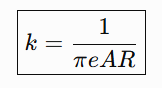

**INDUCED DRAG**

In [24]:
# ============================================================
# INDUCED DRAG
# ============================================================

CDi = (
    k
    * CL_cruise**2
)

print(
    f"Induced drag coefficient CDi = "
    f"{CDi:.5f}"
)

Induced drag coefficient CDi = 0.00155


**TOTAL DRAG COEFFICIENT**

In [25]:
# ============================================================
# TOTAL DRAG COEFFICIENT
# ============================================================

CD_total = (
    CD0
    + CDi
)

print(
    f"CD0      = {CD0:.5f}"
)

print(
    f"CDi      = {CDi:.5f}"
)

print(
    f"CD total = {CD_total:.5f}"
)

CD0      = 0.02425
CDi      = 0.00155
CD total = 0.02579


**LIFT-TO-DRAG RATIO**

In [26]:
# ============================================================
# LIFT-TO-DRAG RATIO
# ============================================================

L_D = (
    CL_cruise
    / CD_total
)

print(
    f"L/D = {L_D:.2f}"
)

L/D = 7.31


**DRAG FORCE**

In [27]:
# ============================================================
# DRAG FORCE
# ============================================================

drag_N = (
    q_cruise
    * wing_area_m2
    * CD_total
)

print(
    f"Drag = {drag_N:.1f} N"
)

Drag = 2266.1 N


**REQUIRED PROPELLER SHAFT POWER**

In [28]:
# ============================================================
# REQUIRED PROPELLER SHAFT POWER
# ============================================================
#
# P_propulsive = D * V
#
# P_shaft = D * V / eta_p
# ============================================================

propeller_efficiency = 0.85

power_required_W = (
    drag_N
    * cruise_speed_ms
    / propeller_efficiency
)

power_required_kW = (
    power_required_W / 1000
)

print(
    f"Required shaft power = "
    f"{power_required_kW:.1f} kW"
)

Required shaft power = 411.5 kW


**POWER MARGIN**

In [29]:
# ============================================================
# AVAILABLE POWER
# ============================================================

available_shaft_power_kW = 650.0

power_margin_kW = (
    available_shaft_power_kW
    - power_required_kW
)

power_margin_fraction = (
    power_margin_kW
    / available_shaft_power_kW
)

print(
    f"Available power : "
    f"{available_shaft_power_kW:.1f} kW"
)

print(
    f"Required power  : "
    f"{power_required_kW:.1f} kW"
)

print(
    f"Power margin    : "
    f"{power_margin_kW:.1f} kW"
)

print(
    f"Margin fraction : "
    f"{power_margin_fraction:.1%}"
)

Available power : 650.0 kW
Required power  : 411.5 kW
Power margin    : 238.5 kW
Margin fraction : 36.7%


**DRAG POLAR**

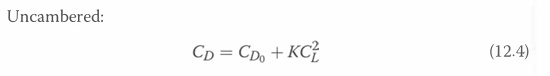

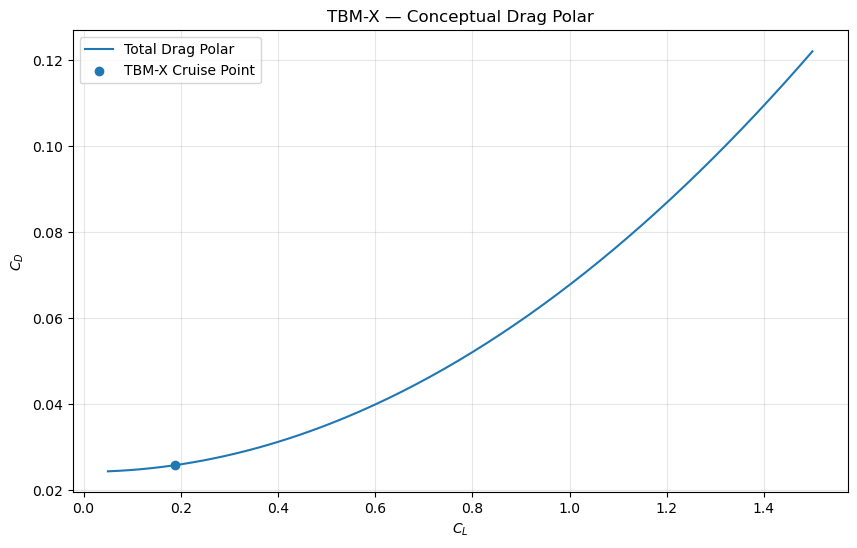

In [30]:
# ============================================================
# DRAG POLAR
# ============================================================

CL_range = np.linspace(
    0.05,
    1.5,
    200
)

CD_parasite = np.full_like(
    CL_range,
    CD0
)

CD_induced = (
    k
    * CL_range**2
)

CD_polar = (
    CD_parasite
    + CD_induced
)

plt.figure(figsize=(10, 6))

plt.plot(
    CL_range,
    CD_polar,
    label="Total Drag Polar"
)

plt.scatter(
    [CL_cruise],
    [CD_total],
    label="TBM-X Cruise Point"
)

plt.xlabel("$C_L$")
plt.ylabel("$C_D$")
plt.title("TBM-X — Conceptual Drag Polar")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

**PARASITE VS INDUCED DRAG**

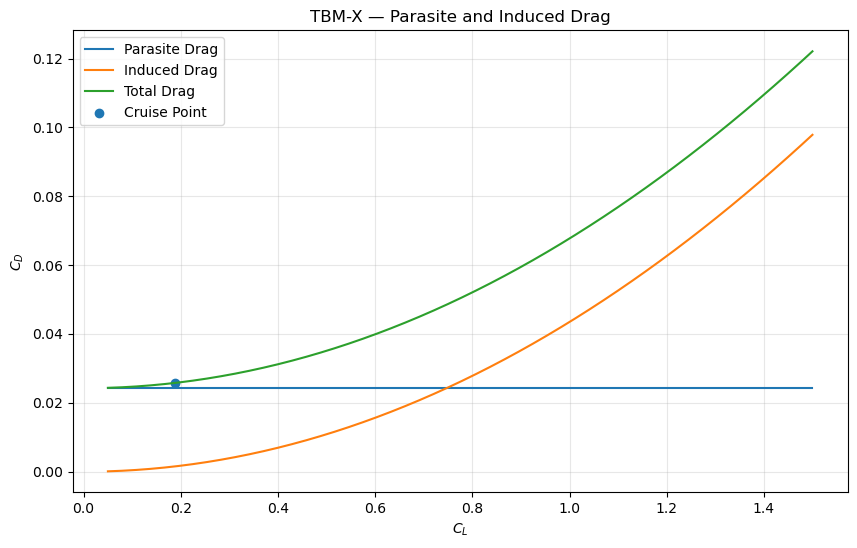

In [31]:
# ============================================================
# PARASITE VS INDUCED DRAG
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    CL_range,
    CD_parasite,
    label="Parasite Drag"
)

plt.plot(
    CL_range,
    CD_induced,
    label="Induced Drag"
)

plt.plot(
    CL_range,
    CD_polar,
    label="Total Drag"
)

plt.scatter(
    [CL_cruise],
    [CD_total],
    label="Cruise Point"
)

plt.xlabel("$C_L$")
plt.ylabel("$C_D$")
plt.title("TBM-X — Parasite and Induced Drag")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

**L/D POLAR**

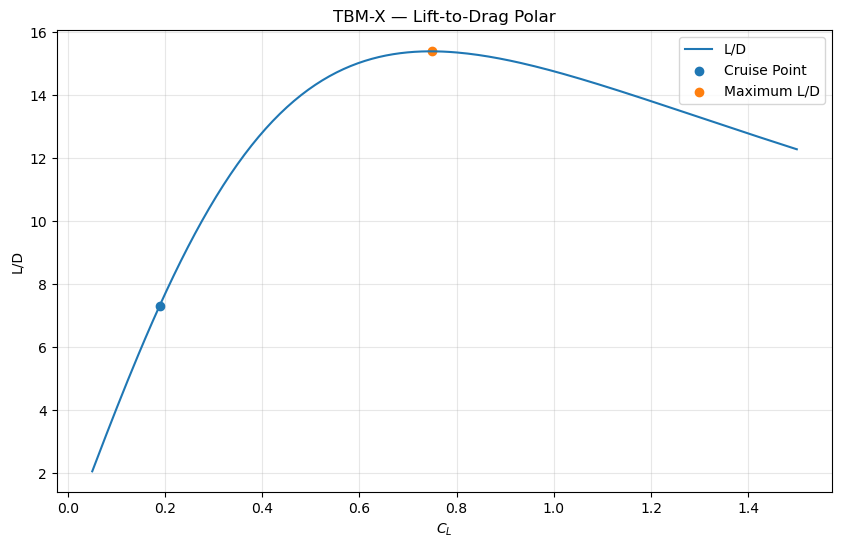

In [33]:
# ============================================================
# L/D POLAR
# ============================================================

L_D_range = (
    CL_range
    / CD_polar
)

max_L_D_index = np.argmax(
    L_D_range
)

CL_max_LD = CL_range[
    max_L_D_index
]

max_L_D = L_D_range[
    max_L_D_index
]

plt.figure(figsize=(10, 6))

plt.plot(
    CL_range,
    L_D_range,
    label="L/D"
)

plt.scatter(
    [CL_cruise],
    [L_D],
    label="Cruise Point"
)

plt.scatter(
    [CL_max_LD],
    [max_L_D],
    label="Maximum L/D"
)

plt.xlabel("$C_L$")
plt.ylabel("L/D")
plt.title("TBM-X — Lift-to-Drag Polar")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

**MAXIMUM L/D**

In [34]:
# ============================================================
# MAXIMUM L/D
# ============================================================

print(
    f"CL at maximum L/D = "
    f"{CL_max_LD:.4f}"
)

print(
    f"Maximum L/D = "
    f"{max_L_D:.2f}"
)

print(
    f"Cruise L/D = "
    f"{L_D:.2f}"
)

CL at maximum L/D = 0.7495
Maximum L/D = 15.40
Cruise L/D = 7.31


**SPEED SWEEP**

In [36]:
# ============================================================
# SPEED SWEEP
# ============================================================

speed_kt_range = np.linspace(
    120,
    350,
    150
)

speed_ms_range = (
    speed_kt_range
    * 0.514444
)

CL_speed = np.zeros_like(
    speed_ms_range
)

CD_speed = np.zeros_like(
    speed_ms_range
)

drag_speed_N = np.zeros_like(
    speed_ms_range
)

power_speed_kW = np.zeros_like(
    speed_ms_range
)

for i, V in enumerate(speed_ms_range):

    q = (
        0.5
        * rho_cruise
        * V**2
    )

    CL = (
        weight_N
        / (
            q
            * wing_area_m2
        )
    )

    CD = (
        CD0
        + k * CL**2
    )

    D = (
        q
        * wing_area_m2
        * CD
    )

    P = (
        D * V
        / propeller_efficiency
        / 1000
    )

    CL_speed[i] = CL
    CD_speed[i] = CD
    drag_speed_N[i] = D
    power_speed_kW[i] = P

**DRAG VS SPEED**

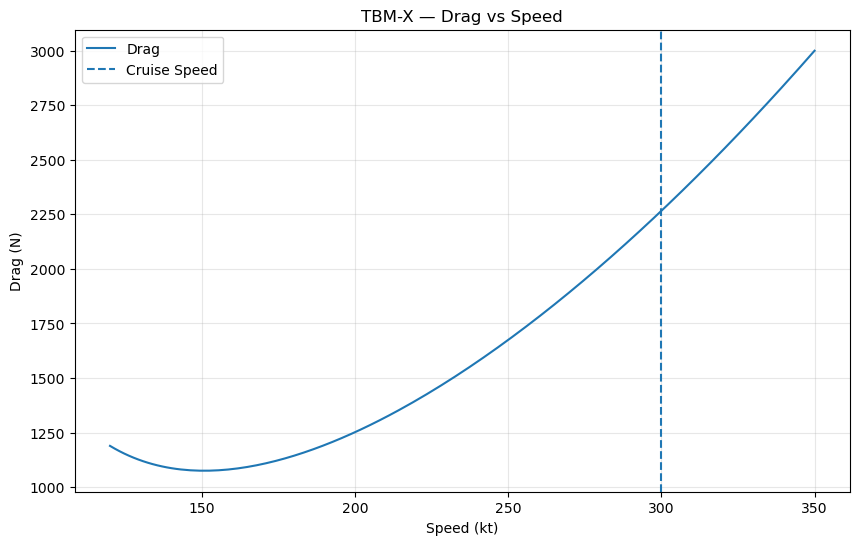

In [38]:
# ============================================================
# DRAG VS SPEED
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    speed_kt_range,
    drag_speed_N,
    label="Drag"
)

plt.axvline(
    cruise_speed_kt,
    linestyle="--",
    label="Cruise Speed"
)

plt.xlabel("Speed (kt)")
plt.ylabel("Drag (N)")
plt.title("TBM-X — Drag vs Speed")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

**POWER REQUIRED VS SPEED**

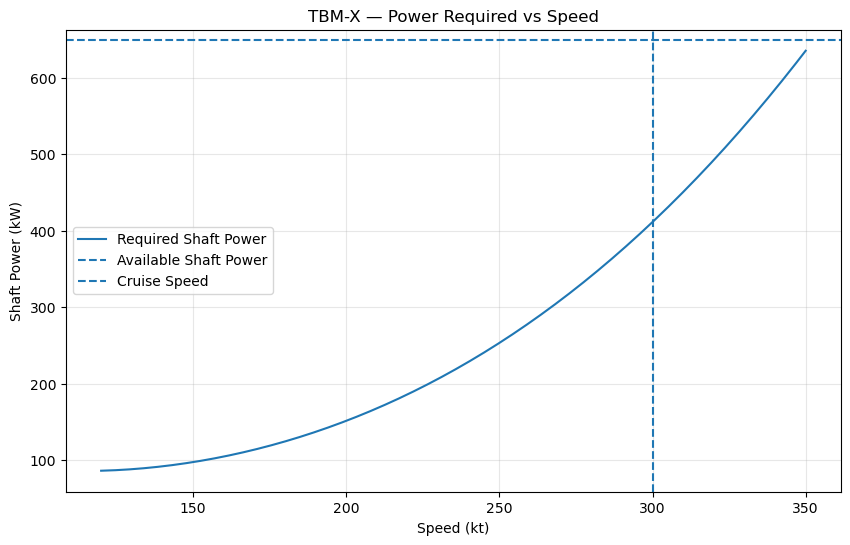

In [39]:
# ============================================================
# POWER REQUIRED VS SPEED
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    speed_kt_range,
    power_speed_kW,
    label="Required Shaft Power"
)

plt.axhline(
    available_shaft_power_kW,
    linestyle="--",
    label="Available Shaft Power"
)

plt.axvline(
    cruise_speed_kt,
    linestyle="--",
    label="Cruise Speed"
)

plt.xlabel("Speed (kt)")
plt.ylabel("Shaft Power (kW)")
plt.title("TBM-X — Power Required vs Speed")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

**MINIMUM POWER**

In [40]:
# ============================================================
# MINIMUM POWER REQUIRED
# ============================================================

min_power_index = np.argmin(
    power_speed_kW
)

min_power_kW = power_speed_kW[
    min_power_index
]

speed_min_power_kt = speed_kt_range[
    min_power_index
]

print(
    f"Minimum power required = "
    f"{min_power_kW:.1f} kW"
)

print(
    f"Speed for minimum power = "
    f"{speed_min_power_kt:.1f} kt"
)

Minimum power required = 86.4 kW
Speed for minimum power = 120.0 kt


**AERODYNAMIC MODEL PROVENANCE**

In [41]:
# ============================================================
# AERODYNAMIC PARAMETER PROVENANCE
# ============================================================

aero_provenance = pd.DataFrame([
    {
        "Parameter": "CD0",
        "Value": CD0,
        "Method": (
            "Cf × Swet/S × Q + CD_misc"
        ),
        "Origin": (
            "Raymer-inspired conceptual model "
            "+ engineering assumptions"
        ),
        "Status": "Preliminary"
    },

    {
        "Parameter": "Cf",
        "Value": Cf_cruise,
        "Method": "Turbulent flat-plate correlation",
        "Origin": "Engineering correlation",
        "Status": "Preliminary"
    },

    {
        "Parameter": "Swet/S",
        "Value": wetted_area_ratio,
        "Method": "Conceptual wetted-area ratio",
        "Origin": "Engineering Assumption",
        "Status": "Preliminary"
    },

    {
        "Parameter": "Q",
        "Value": form_interference_factor,
        "Method": "Form/interference factor",
        "Origin": "Engineering Assumption",
        "Status": "Preliminary"
    },

    {
        "Parameter": "CD_misc",
        "Value": CD_misc,
        "Method": "Miscellaneous drag allowance",
        "Origin": "Engineering Assumption",
        "Status": "Preliminary"
    },

    {
        "Parameter": "e",
        "Value": oswald_efficiency,
        "Method": "Oswald efficiency",
        "Origin": "Engineering Assumption",
        "Status": "Preliminary"
    },

    {
        "Parameter": "AR",
        "Value": aspect_ratio,
        "Method": "Wing geometry",
        "Origin": "Geometry sizing / benchmark-informed",
        "Status": "Preliminary"
    },

    {
        "Parameter": "k",
        "Value": k,
        "Method": "1 / (π e AR)",
        "Origin": "Physics",
        "Status": "Calculated"
    },
])

aero_provenance

,Parameter,Value,Method,Origin,Status
0,CD0,0.024246,Cf × Swet/S × Q + CD_misc,Raymer-inspired conceptual model + engineering...,Preliminary
1,Cf,0.003208,Turbulent flat-plate correlation,Engineering correlation,Preliminary
2,Swet/S,5.000000,Conceptual wetted-area ratio,Engineering Assumption,Preliminary
3,Q,1.200000,Form/interference factor,Engineering Assumption,Preliminary
4,CD_misc,0.005000,Miscellaneous drag allowance,Engineering Assumption,Preliminary
5,e,0.800000,Oswald efficiency,Engineering Assumption,Preliminary
6,AR,9.150000,Wing geometry,Geometry sizing / benchmark-informed,Preliminary
7,k,0.043485,1 / (π e AR),Physics,Calculated


**AERODYNAMIC SUMMARY**

In [42]:
# ============================================================
# AERODYNAMIC SUMMARY
# ============================================================

aero_summary = pd.Series({
    "MTOW (kg)": MTOW_kg,

    "Wing Area (m²)": wing_area_m2,

    "Aspect Ratio": aspect_ratio,

    "Reynolds Number":
        Re_cruise,

    "CL Cruise":
        CL_cruise,

    "CD0":
        CD0,

    "CDi":
        CDi,

    "CD Total":
        CD_total,

    "k":
        k,

    "L/D Cruise":
        L_D,

    "Maximum L/D":
        max_L_D,

    "Required Power (kW)":
        power_required_kW,

    "Available Power (kW)":
        available_shaft_power_kW,

    "Power Margin (%)":
        power_margin_fraction * 100,
})

aero_summary

MTOW (kg)               1.689000e+03
Wing Area (m²)          1.344000e+01
Aspect Ratio            9.150000e+00
Reynolds Number         6.668536e+06
CL Cruise               1.885094e-01
CD0                     2.424584e-02
CDi                     1.545272e-03
CD Total                2.579112e-02
k                       4.348496e-02
L/D Cruise              7.309081e+00
Maximum L/D             1.539851e+01
Required Power (kW)     4.114604e+02
Available Power (kW)    6.500000e+02
Power Margin (%)        3.669841e+01
dtype: float64

**AERODYNAMIC SANITY CHECKS**

In [44]:
# ============================================================
# AERODYNAMIC SANITY CHECKS
# ============================================================

checks = []

# CL
if CL_cruise < 0.2:
    checks.append(
        "WARNING: Cruise CL is unusually low."
    )

elif CL_cruise > 0.8:
    checks.append(
        "WARNING: Cruise CL is relatively high."
    )

else:
    checks.append(
        "PASS: Cruise CL is within a plausible conceptual range."
    )


# CD0
if CD0 < 0.015:
    checks.append(
        "WARNING: CD0 may be unrealistically optimistic."
    )

elif CD0 > 0.05:
    checks.append(
        "WARNING: CD0 is relatively high."
    )

else:
    checks.append(
        "PASS: CD0 is within a plausible conceptual range."
    )


# L/D
if L_D < 8:
    checks.append(
        "WARNING: Cruise L/D is low."
    )

elif L_D > 25:
    checks.append(
        "WARNING: Cruise L/D is unusually high."
    )

else:
    checks.append(
        "PASS: Cruise L/D is plausible."
    )


# Power
if power_margin_fraction < 0:
    checks.append(
        "WARNING: Required power exceeds available power."
    )

else:
    checks.append(
        "PASS: Available power exceeds required cruise power."
    )


for check in checks:
    print("-", check)

- WARNING: Cruise CL is unusually low.
- PASS: CD0 is within a plausible conceptual range.
- WARNING: Cruise L/D is low.
- PASS: Available power exceeds required cruise power.


**SAVE AERODYNAMIC RESULTS**

In [45]:
# ============================================================
# SAVE AERODYNAMIC RESULTS
# ============================================================

output_dir = current_dir / "outputs"

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

aero_output_path = (
    output_dir
    / "TBM_X_aerodynamic_summary.csv"
)

aero_summary.to_csv(
    aero_output_path,
    header=["Value"]
)

print(
    "Aerodynamic summary saved to:"
)

print(
    aero_output_path.resolve()
)

Aerodynamic summary saved to:
C:\Users\musta\Documents\RAYMER\TBM-X_v0.2_data_engineering\outputs\TBM_X_aerodynamic_summary.csv


**FINAL DESIGN VECTOR**

In [46]:
# ============================================================
# TBM-X AERODYNAMIC DESIGN VECTOR
# ============================================================

aero_design_vector = pd.DataFrame([{
    "MTOW_kg":
        MTOW_kg,

    "wing_area_m2":
        wing_area_m2,

    "aspect_ratio":
        aspect_ratio,

    "CL_cruise":
        CL_cruise,

    "CD0":
        CD0,

    "CDi":
        CDi,

    "CD_total":
        CD_total,

    "k":
        k,

    "L_D_cruise":
        L_D,

    "max_L_D":
        max_L_D,

    "power_required_kW":
        power_required_kW,

    "power_available_kW":
        available_shaft_power_kW,

    "power_margin_fraction":
        power_margin_fraction,

    "Re_cruise":
        Re_cruise,
}])

aero_design_vector

,MTOW_kg,wing_area_m2,aspect_ratio,CL_cruise,CD0,CDi,CD_total,k,L_D_cruise,max_L_D,power_required_kW,power_available_kW,power_margin_fraction,Re_cruise
0,1689.0,13.44,9.15,0.188509,0.024246,0.001545,0.025791,0.043485,7.309081,15.398513,411.460361,650.0,0.366984,6.668536e+06


**FINAL STATEMENT**

In [47]:
# ============================================================
# FINAL ENGINEERING STATEMENT
# ============================================================

print("""
============================================================
TBM-X — AERODYNAMIC MODEL
============================================================

The aerodynamic model has now been upgraded from a simple
constant-CD0 assumption to a physics-informed conceptual model.

PARASITE DRAG
-------------
Reynolds number
      ↓
Skin friction coefficient Cf
      ↓
Wetted area ratio
      ↓
Form/interference factor
      ↓
CD0_skin
      ↓
Miscellaneous drag
      ↓
Total CD0

INDUCED DRAG
------------
Aspect Ratio
      +
Oswald efficiency
      ↓
k = 1 / (π e AR)
      ↓
CDi = k CL²

TOTAL DRAG
----------
CD = CD0 + CDi

PERFORMANCE LINK
----------------
CD → Drag → Required Shaft Power

This model is still conceptual.

The next iterations should improve:
    - component-level wetted areas
    - fuselage drag
    - wing drag
    - tail drag
    - nacelle / engine installation drag
    - interference drag
    - compressibility effects
    - Reynolds-number effects
    - Oswald efficiency correlation

NEXT STEP
---------
08 — PROPULSION MODEL

============================================================
""")


TBM-X — AERODYNAMIC MODEL

The aerodynamic model has now been upgraded from a simple
constant-CD0 assumption to a physics-informed conceptual model.

PARASITE DRAG
-------------
Reynolds number
      ↓
Skin friction coefficient Cf
      ↓
Wetted area ratio
      ↓
Form/interference factor
      ↓
CD0_skin
      ↓
Miscellaneous drag
      ↓
Total CD0

INDUCED DRAG
------------
Aspect Ratio
      +
Oswald efficiency
      ↓
k = 1 / (π e AR)
      ↓
CDi = k CL²

TOTAL DRAG
----------
CD = CD0 + CDi

PERFORMANCE LINK
----------------
CD → Drag → Required Shaft Power

This model is still conceptual.

The next iterations should improve:
    - component-level wetted areas
    - fuselage drag
    - wing drag
    - tail drag
    - nacelle / engine installation drag
    - interference drag
    - compressibility effects
    - Reynolds-number effects
    - Oswald efficiency correlation

NEXT STEP
---------
08 — PROPULSION MODEL


